# Phase 2 — Can it learn?

Phase 1 proved the architecture *runs*. This proves it *learns*, on a task with no data pipeline in the way: copy a sequence of random integers, then reverse it.

Trivial for a transformer — and that is the point. The two bugs that sink seq2seq builds, an off-by-one in the teacher-forcing shift and a mask that leaks the future, are silent on real text. Here they are unmissable.

In [1]:
import math
import os
import sys

for candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(candidate, "src")):
        sys.path.insert(0, candidate)
        break

import matplotlib.pyplot as plt
import torch

from src.config import TransformerConfig, get_device
from src.inference import cross_attention_map, exact_match, greedy_decode, strip_special
from src.toy_data import describe, make_batch
from src.train import overfit_batch, train
from src.transformer import build_model

%matplotlib inline
device = get_device()
torch.manual_seed(0)

VOCAB = 50
print("Device:", device)

Device: cuda


## 1. The data

Each batch is three tensors. `tgt_in` and `tgt_out` are the same sequence offset by one — feeding `tgt_in` at position *t* should predict `tgt_out` at position *t*.

Lengths vary within a batch on purpose: that exercises padding, and padding is where mask bugs hide.

In [2]:
batch = make_batch(batch_size=16, vocab_size=VOCAB, min_len=4, max_len=8,
                   task="copy", device=device)

print(describe(*batch))
print()
print("shapes:", [tuple(t.shape) for t in batch])

src      12  42  28  13  16  25  43  30   2
tgt_in    1  12  42  28  13  16  25  43  30
tgt_out  12  42  28  13  16  25  43  30   2

shapes: [(16, 9), (16, 9), (16, 9)]


## 2. Overfit one batch

The cheapest possible check. Train on a *single* batch until the model memorises it — loss should collapse towards zero.

If it cannot memorise 16 sequences, the problem is a bug, not the data or the hyperparameters. Dropout is off here; it puts a floor under the loss and hides exactly what we want to see.

In [3]:
cfg_overfit = TransformerConfig(vocab_size=VOCAB, d_model=128, num_heads=4,
                                num_layers=2, d_ff=512, dropout=0.0, max_len=64)

model = build_model(cfg_overfit).to(device)
history = overfit_batch(model, batch, steps=400, log_every=100)

print()
print("final loss %.6f   accuracy %.1f%%" % (history["loss"][-1], 100 * history["acc"][-1]))

step     1   loss 7.9178   acc  0.8%
step   100   loss 0.0273   acc 100.0%
step   200   loss 0.0073   acc 100.0%
step   300   loss 0.0031   acc 100.0%
step   400   loss 0.0015   acc 100.0%

final loss 0.001453   accuracy 100.0%


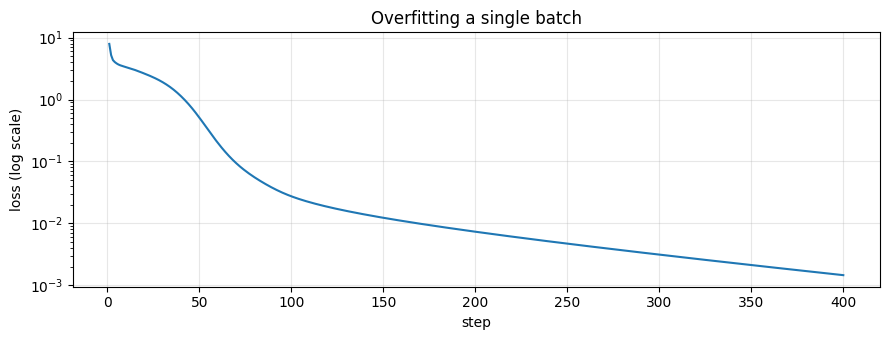

In [4]:
plt.figure(figsize=(9, 3.5))
plt.plot(history["step"], history["loss"])
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss (log scale)")
plt.title("Overfitting a single batch")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Train on the copy task

Now a fresh batch every step, so the model never sees the same sequences twice. It has to learn the *rule*, not the data.

Dropout is back on, and so is label smoothing — which means the loss will **not** approach zero. Smoothing deliberately holds back probability mass from the correct token, putting an irreducible floor around 0.7 at this vocabulary size. Watch accuracy, not loss.

In [5]:
torch.manual_seed(0)

cfg = TransformerConfig(vocab_size=VOCAB, d_model=128, num_heads=4,
                        num_layers=2, d_ff=512, dropout=0.1, max_len=64)

copy_model = build_model(cfg).to(device)

def copy_batch():
    return make_batch(batch_size=64, vocab_size=VOCAB, min_len=4, max_len=10,
                      task="copy", device=device)

copy_history = train(copy_model, copy_batch, steps=1500, log_every=300)

step     1   loss 7.0347   acc  2.4%
step   300   loss 1.3609   acc 77.5%
step   600   loss 0.8020   acc 98.4%
step   900   loss 0.7525   acc 99.6%
step  1200   loss 0.7524   acc 99.2%
step  1500   loss 0.7262   acc 99.8%


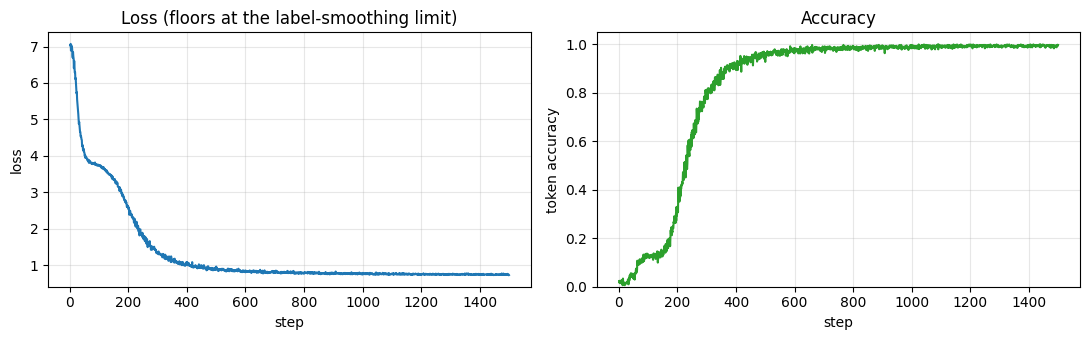

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(copy_history["step"], copy_history["loss"])
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")
axes[0].set_title("Loss (floors at the label-smoothing limit)")
axes[0].grid(alpha=0.3)

axes[1].plot(copy_history["step"], copy_history["acc"], color="tab:green")
axes[1].set_xlabel("step"); axes[1].set_ylabel("token accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Decode

Training runs the whole target through at once. Generation cannot — the input at step *t* is the model's own output from step *t-1*. So the encoder runs once and the decoder runs once per token.

This is the first output produced without ever being shown the answer.

In [7]:
src, tgt_in, tgt_out = copy_batch()
pred = greedy_decode(copy_model, src)

print("exact match: %.1f%%" % (100 * exact_match(pred, tgt_out)))
print()
for i in range(3):
    print("src ", strip_special(src[i]))
    print("pred", strip_special(pred[i]))
    print()

exact match: 100.0%

src  [15, 20, 45, 46, 19, 48, 35, 44]
pred [15, 20, 45, 46, 19, 48, 35, 44]

src  [49, 12, 25, 4, 19, 6, 6, 19, 13, 42]
pred [49, 12, 25, 4, 19, 6, 6, 19, 13, 42]

src  [28, 25, 5, 49, 19, 18, 12, 21, 33]
pred [28, 25, 5, 49, 19, 18, 12, 21, 33]



## 5. What the model learned

Cross-attention is the decoder looking at the encoder — for each output position, how much of each input position it used.

On a trained copy model it should be a clean **diagonal**: output 3 attends to input 3. This is the first time attention does something meaningful rather than producing correctly-shaped noise.

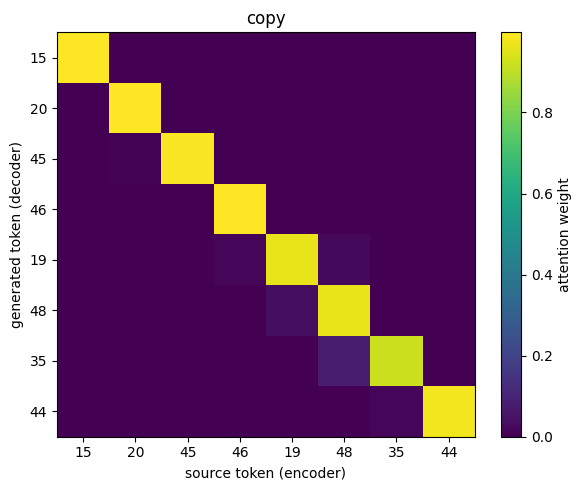

In [8]:
def plot_attention(model, src, tgt_in, title, ax):
    attn = cross_attention_map(model, src, tgt_in)[0].cpu()
    source = strip_special(src[0])
    n_out = len(source)

    im = ax.imshow(attn[:n_out, :len(source)].numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(source)), source)
    ax.set_yticks(range(n_out), source if title == "copy" else source[::-1])
    ax.set_xlabel("source token (encoder)")
    ax.set_ylabel("generated token (decoder)")
    ax.set_title(title)
    return im


fig, ax = plt.subplots(figsize=(6, 5))
im = plot_attention(copy_model, src, tgt_in, "copy", ax)
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

## 6. Reverse — the harder check

Copy could in principle be solved by ignoring the source and learning position identity. Reverse cannot: output position 0 must fetch input position *n*.

If the alignment mechanism genuinely works, the same architecture with no changes should produce an **anti-diagonal**.

In [9]:
torch.manual_seed(0)

reverse_model = build_model(cfg).to(device)

def reverse_batch():
    return make_batch(batch_size=64, vocab_size=VOCAB, min_len=4, max_len=10,
                      task="reverse", device=device)

reverse_history = train(reverse_model, reverse_batch, steps=1500, log_every=300)

step     1   loss 7.0470   acc  2.4%
step   300   loss 1.8758   acc 57.6%
step   600   loss 1.0262   acc 91.3%
step   900   loss 0.8801   acc 95.3%
step  1200   loss 0.8122   acc 97.0%
step  1500   loss 0.8005   acc 98.0%


In [10]:
src_r, tgt_in_r, tgt_out_r = reverse_batch()
pred_r = greedy_decode(reverse_model, src_r)

print("exact match: %.1f%%" % (100 * exact_match(pred_r, tgt_out_r)))
print()
print("src ", strip_special(src_r[0]))
print("pred", strip_special(pred_r[0]))

exact match: 100.0%

src  [15, 20, 45, 46, 19, 48, 35, 44]
pred [44, 35, 48, 19, 46, 45, 20, 15]


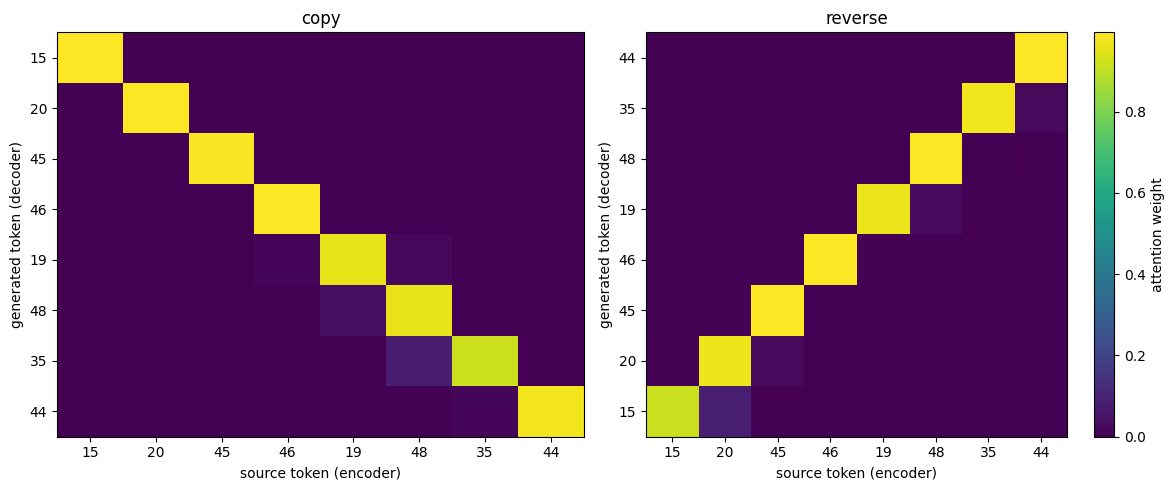

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_attention(copy_model, src, tgt_in, "copy", axes[0])
im = plot_attention(reverse_model, src_r, tgt_in_r, "reverse", axes[1])
plt.colorbar(im, ax=axes[1], label="attention weight")
plt.tight_layout()
plt.show()

## Done

Diagonal for copy, anti-diagonal for reverse — the model is genuinely reading the source and routing the right position to the right output step. Combined with near-perfect exact match, that clears the gate: the architecture learns, the teacher-forcing shift is right, and the masks are doing their job.

Next is real data — vocabulary, the Shakespeare corpus, and the copy baseline to beat.